# 02 — Exploratory Data Analysis

Understand the dataset before modelling:
- Price & volume distributions
- Return statistics and autocorrelation
- Label balance per horizon (class imbalance check)
- Missing data audit
- Temporal patterns (hour / day-of-week effects)

In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
PROCESSED = ROOT / 'data' / 'processed'

In [4]:
# Load all three resampled datasets
frames = {}
for label in ['5m', '30m', '1h']:
    path = PROCESSED / f'btc_{label}.csv'
    frames[label] = pd.read_csv(path, index_col='timestamp', parse_dates=True)
    print(f"{label:>4s}: {len(frames[label]):,} rows  "
          f"({frames[label].index[0].date()} → {frames[label].index[-1].date()})")

  5m: 758,593 rows  (2019-01-01 → 2026-03-19)
 30m: 126,433 rows  (2019-01-01 → 2026-03-19)
  1h: 63,217 rows  (2019-01-01 → 2026-03-19)


## 1. Price Chart

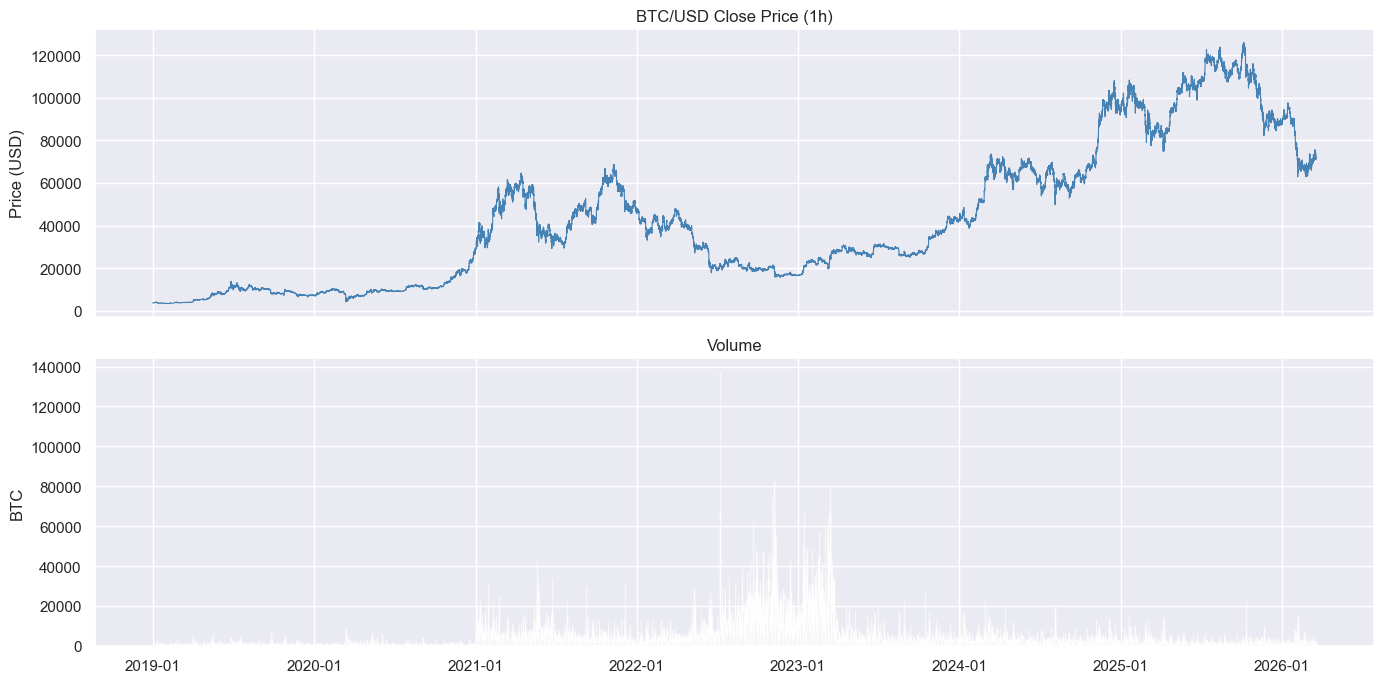

In [5]:
df = frames['1h']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df.index, df['close'], linewidth=0.8, color='steelblue')
axes[0].set_title('BTC/USD Close Price (1h)')
axes[0].set_ylabel('Price (USD)')

axes[1].bar(df.index, df['volume'], width=0.03, color='gray', alpha=0.6)
axes[1].set_title('Volume')
axes[1].set_ylabel('BTC')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

## 2. Return Distributions

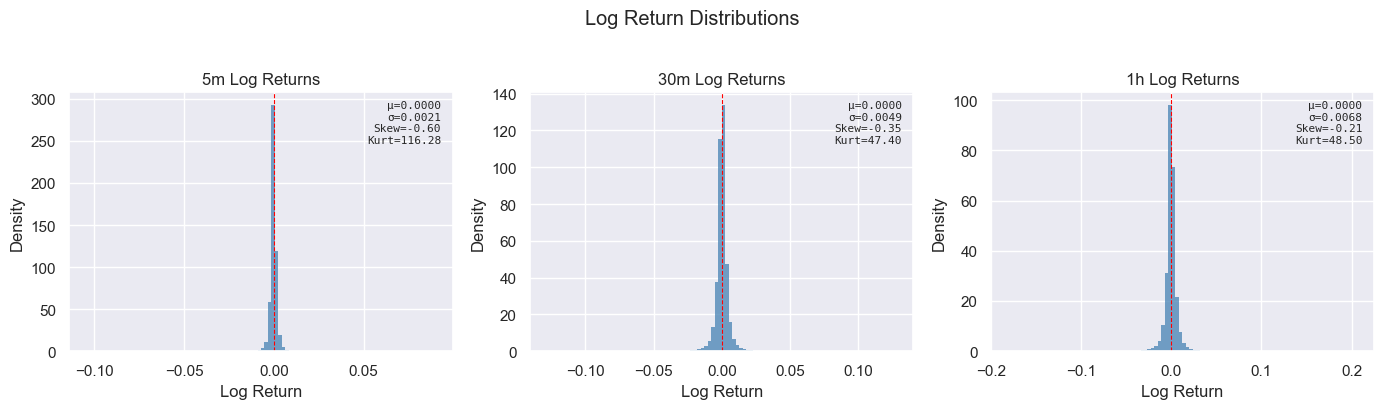

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, df) in zip(axes, frames.items()):
    ret = np.log(df['close'] / df['close'].shift(1)).dropna()
    ax.hist(ret, bins=100, density=True, color='steelblue', alpha=0.75, edgecolor='none')
    ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} Log Returns')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')

    stats = f'μ={ret.mean():.4f}\nσ={ret.std():.4f}\nSkew={ret.skew():.2f}\nKurt={ret.kurtosis():.2f}'
    ax.text(0.97, 0.97, stats, transform=ax.transAxes, fontsize=8,
            va='top', ha='right', family='monospace')

plt.suptitle('Log Return Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 3. Return Autocorrelation

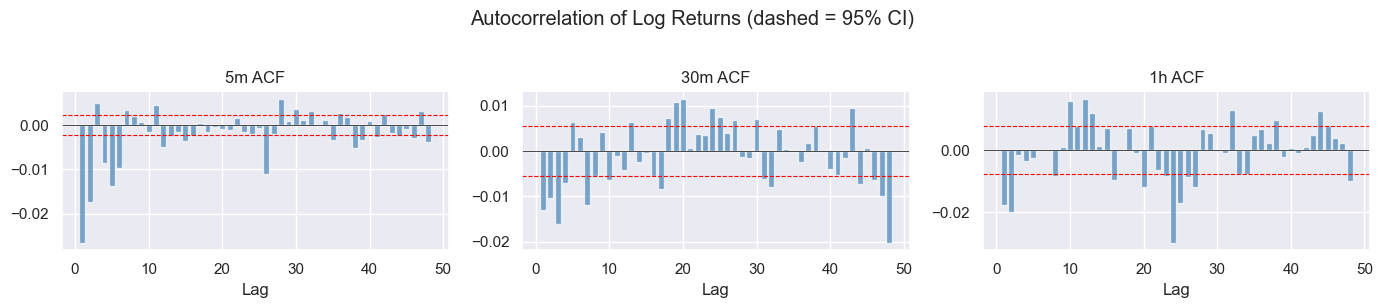

In [7]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, (label, df) in zip(axes, frames.items()):
    ret = np.log(df['close'] / df['close'].shift(1)).dropna()
    lags = range(1, 49)
    acf = [ret.autocorr(lag=k) for k in lags]
    conf = 1.96 / np.sqrt(len(ret))
    ax.bar(list(lags), acf, color='steelblue', alpha=0.7)
    ax.axhline(conf,  color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-conf, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{label} ACF')
    ax.set_xlabel('Lag')

plt.suptitle('Autocorrelation of Log Returns (dashed = 95% CI)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Label Balance (class imbalance check)

In [8]:
print('Label balance (fraction of UP candles):')
print('Horizon | UP rate')
print('--------|--------')
for label, df in frames.items():
    up_rate = (df['close'].shift(-1) > df['close']).mean()
    print(f'{label:>7s} | {up_rate:.4f}')

Label balance (fraction of UP candles):
Horizon | UP rate
--------|--------
     5m | 0.4998
    30m | 0.5065
     1h | 0.5076


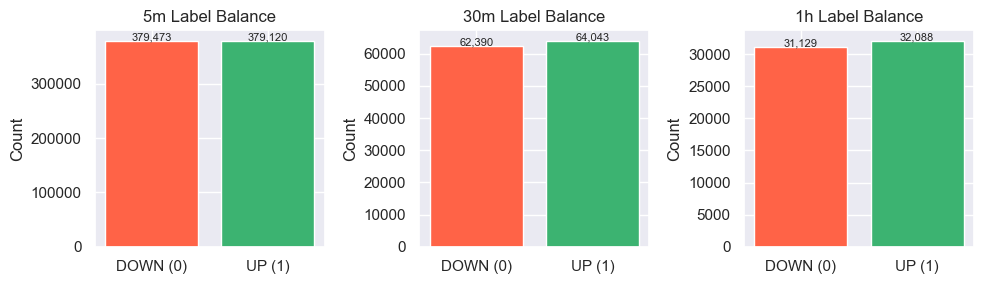

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, (label, df) in zip(axes, frames.items()):
    target = (df['close'].shift(-1) > df['close']).dropna().astype(int)
    counts = target.value_counts().sort_index()
    ax.bar(['DOWN (0)', 'UP (1)'], counts.values, color=['tomato', 'mediumseagreen'])
    ax.set_title(f'{label} Label Balance')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Missing Data Audit

In [10]:
for label, df in frames.items():
    expected_freq = {'5m': '5min', '30m': '30min', '1h': '1h'}[label]
    full_idx = pd.date_range(df.index[0], df.index[-1], freq=expected_freq)
    missing = full_idx.difference(df.index)
    pct = len(missing) / len(full_idx) * 100
    print(f"{label:>4s}: {len(missing):,} missing candles out of {len(full_idx):,} ({pct:.2f}%)")

  5m: 0 missing candles out of 758,593 (0.00%)
 30m: 0 missing candles out of 126,433 (0.00%)
  1h: 0 missing candles out of 63,217 (0.00%)


## 6. Temporal Patterns (hour-of-day, day-of-week)

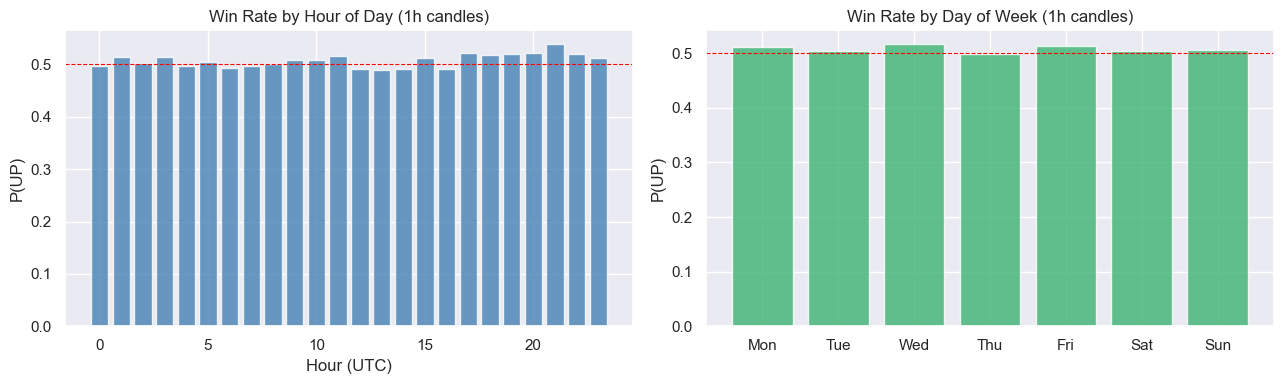

In [11]:
df = frames['1h'].copy()
df['ret'] = np.log(df['close'] / df['close'].shift(1))
df['up'] = (df['ret'] > 0).astype(int)
df['hour'] = df.index.hour
df['dow'] = df.index.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day
hourly = df.groupby('hour')['up'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.8)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('P(UP)')
axes[0].set_title('Win Rate by Hour of Day (1h candles)')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('dow')['up'].mean().reindex(day_order)
axes[1].bar(range(7), daily.values, color='mediumseagreen', alpha=0.8)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_ylabel('P(UP)')
axes[1].set_title('Win Rate by Day of Week (1h candles)')

plt.tight_layout()
plt.show()

## 7. Volume Z-Score Distribution

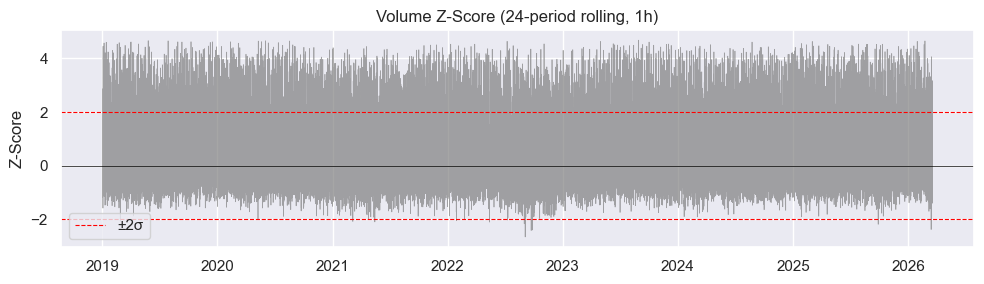

In [12]:
df = frames['1h'].copy()
vol_zscore = (df['volume'] - df['volume'].rolling(24).mean()) / df['volume'].rolling(24).std()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df.index, vol_zscore, linewidth=0.5, color='gray', alpha=0.7)
ax.axhline(2,  color='red',   linestyle='--', linewidth=0.8, label='±2σ')
ax.axhline(-2, color='red',   linestyle='--', linewidth=0.8)
ax.axhline(0,  color='black', linewidth=0.5)
ax.set_title('Volume Z-Score (24-period rolling, 1h)')
ax.set_ylabel('Z-Score')
ax.legend()
plt.tight_layout()
plt.show()